1. Load general dataframe

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import folium
from folium.plugins import HeatMap
from folium.plugins import HeatMapWithTime

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(PROJ, "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(PROJ, "data", "features.csv"), parse_dates=["collected_at"])
df = df[df["is_orphan"] == 0]
print(f"Loaded and orphans filtered... {len(df):,} rows")

Loaded and orphans filtered... 9,215,922 rows


1.1. Check dataframe

In [17]:
print(df.dtypes.to_string())
print(f"\nRows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"\nDate range: {df['collected_at'].min()} → {df['collected_at'].max()}")

collected_at               datetime64[us, UTC]
location_name                              str
destination_name                           str
date                                       str
is_orphan                                int64
hour                                     int64
day_of_week                              int64
is_weekend                               int64
is_rush_hour                             int64
line                                       str
location_code                              str
num_lines                                int64
is_terminal                              int64
lat                                    float64
lon                                    float64
minutes_num                            float64
num_predictions_in_feed                  int64
avg_cars_at_station                    float64
delay_rate_30min                       float64
line_delay_rate_30min                  float64
active_incident                          int64
incident_is_d

2.1. Create dynamic map showing cumulative delays of the week (Monday 00:00 to Sunday 23:00)

In [18]:
list_grouping = ["location_code", "day_of_week", "hour"]#, "line", "destination_name"]
df_delay_stations = df.groupby(by=list_grouping, as_index=False).mean(numeric_only=True)

# Create map centered on stations location
wmata_location = [df_delay_stations['lat'].mean(), df_delay_stations['lon'].mean()]
map = folium.Map(location=wmata_location, zoom_start=12)

dict_dow = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}
delay_list = []
time_index = []

# Iterate over day of week and hour
days_of_week_list = list(range(0, 7))
hours_list = list(range(0, 24))
for dow in days_of_week_list:
    for h in hours_list:
        # The new list is concatenated to the last, for cumulative purposes
        last_list = ([] if (delay_list == []) else (delay_list[-1]))
        new_list = last_list + df_delay_stations.loc[
            (df_delay_stations['day_of_week'] == dow) &
            (df_delay_stations['hour'] == h),
            ['lat', 'lon', 'is_delayed']].values.tolist()
        # append combined list to delay_list
        delay_list.append(new_list)
        str_index = f"Day of week: {dict_dow[dow]} | Hour: {h}:00"
        time_index.append(str_index)

HeatMapWithTime(
    delay_list,
    index=time_index
).add_to(map)
map.save(os.path.join(FIG_DIR, "Map_cumulative_delayed_rate.html"))

# Map is too big to display
#map

2.2. Create map with popup displaying delay rate per station

In [19]:
list_grouping = ["location_code"]#, "day_of_week", "hour", "line", "destination_name"]
df_delay_stations = df.groupby(by=list_grouping, as_index=False).mean(numeric_only=True)
map = folium.Map(location=wmata_location, zoom_start=12)
HeatMap(df_delay_stations[['lat', 'lon', 'is_delayed']].values.tolist()).add_to(map)

# Add popups for every station
for i, record in df_delay_stations.iterrows():
    str_popup = f"Station code: {record['location_code']}. Delayed rate: {record['is_delayed']:.2%}"
    folium.Marker(location=[record['lat'], record['lon']],
                  popup=str_popup,
                  tooltip=str(record['location_code'])).add_to(map)

map.save(os.path.join(FIG_DIR, "Map_popup_delayed_rate.html"))

3. For each line-direction create matrix of delay rate by day day of week and hour

[('BL', 'Downtown Largo'), ('BL', 'Franconia-Springfield'), ('BL', 'LastTrain'), ('BL', 'Metro Ctr'), ('BL', 'Huntington'), ('BL', 'Greenbelt'), ('BL', 'Ronald Reagan Washington National Airport'), ('BL', 'National Air'), ('BL', 'Stadium-Armory'), ('BL', 'Smithsonian'), ('BL', 'MtVern Sq'), ('BL', 'Addisn Rd'), ('BL', 'Mt Vern Sq'), ('BL', 'Addison Rd'), ('BL', 'Eastern Mkt'), ('BL', 'Estrn Mkt'), ('GR', 'Greenbelt'), ('GR', 'Branch Av'), ('GR', 'Branch Ave'), ('GR', 'LastTrain'), ('GR', 'Ft Totten'), ('GR', 'Anacostia'), ('GR', 'Huntington'), ('GR', 'MtVern Sq'), ('GR', 'Mt Vern Sq'), ('GR', 'Collge Pk'), ('GR', 'College Park'), ('GR', 'U Street/African-Amer Civil War Memorial/Cardozo'), ('GR', 'U Street'), ('OR', 'Cheverly'), ('OR', 'Vienna/Fairfax-GMU'), ('OR', 'LastTrain'), ('OR', 'N Carrollton'), ('OR', 'NewCrlton'), ('OR', 'WFalls Chrc'), ('OR', 'WFalls Ch'), ('OR', 'Ashburn'), ('OR', 'Rosslyn'), ('RD', 'Glenmont'), ('RD', 'Shady Grove'), ('RD', 'Shady Grv'), ('RD', 'LastTrain'),

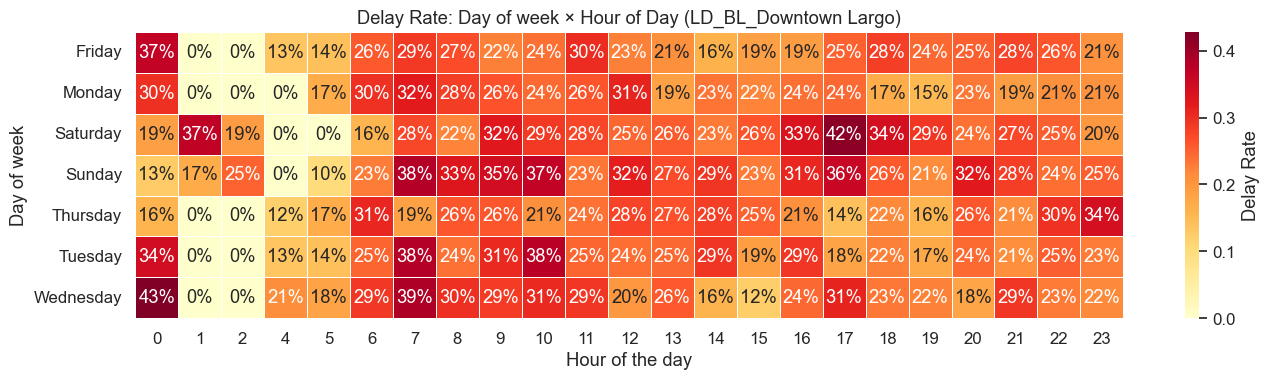

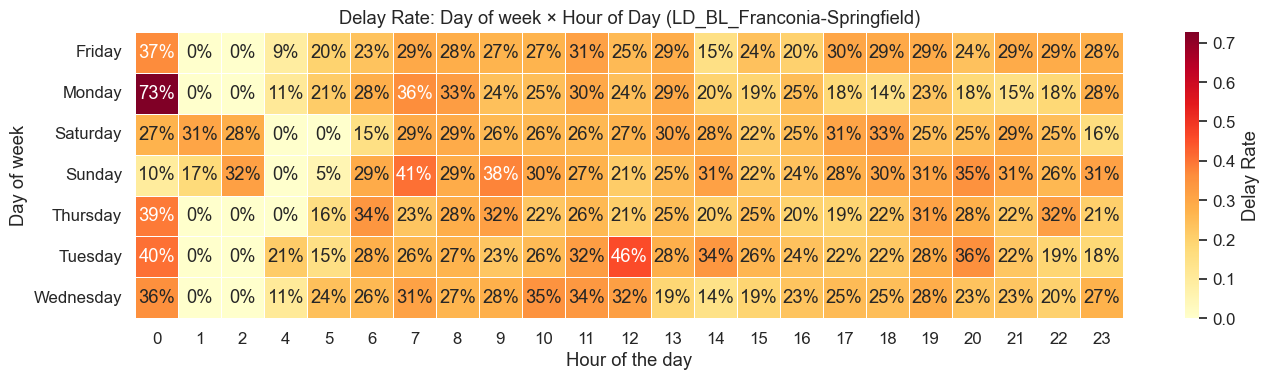

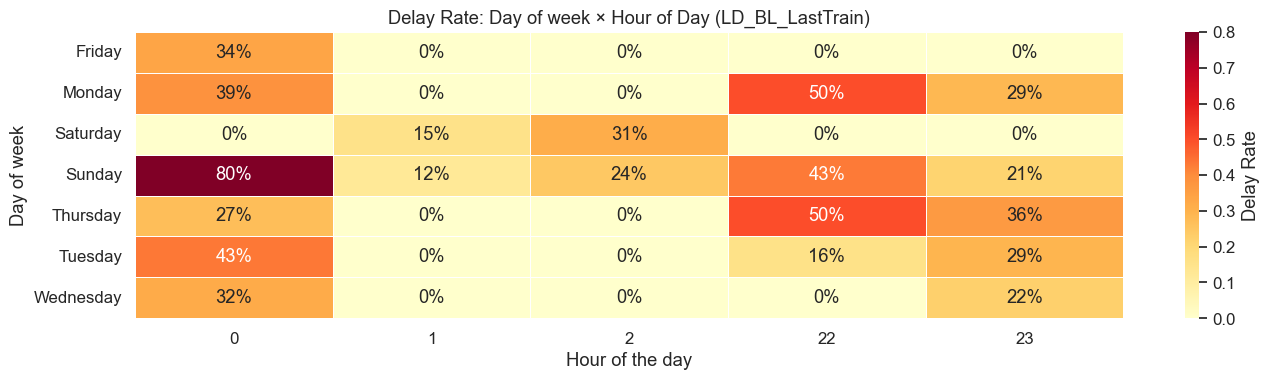

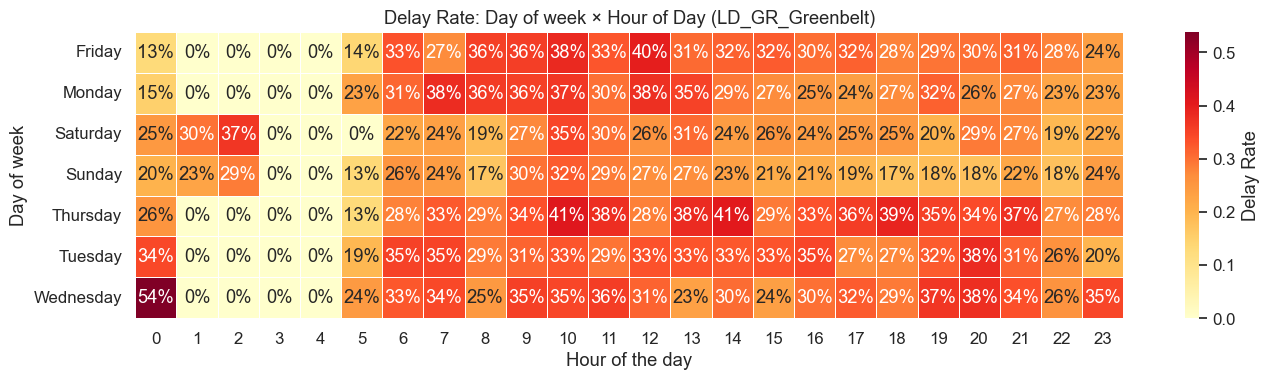

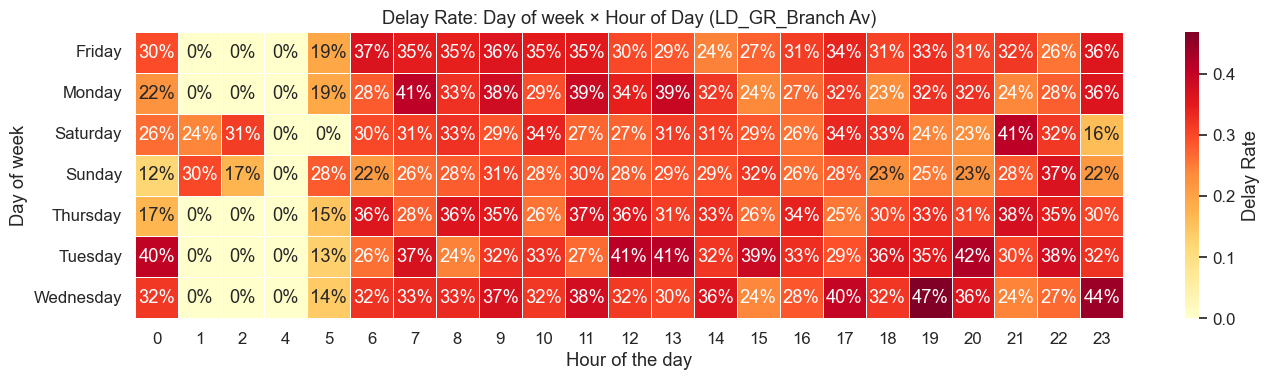

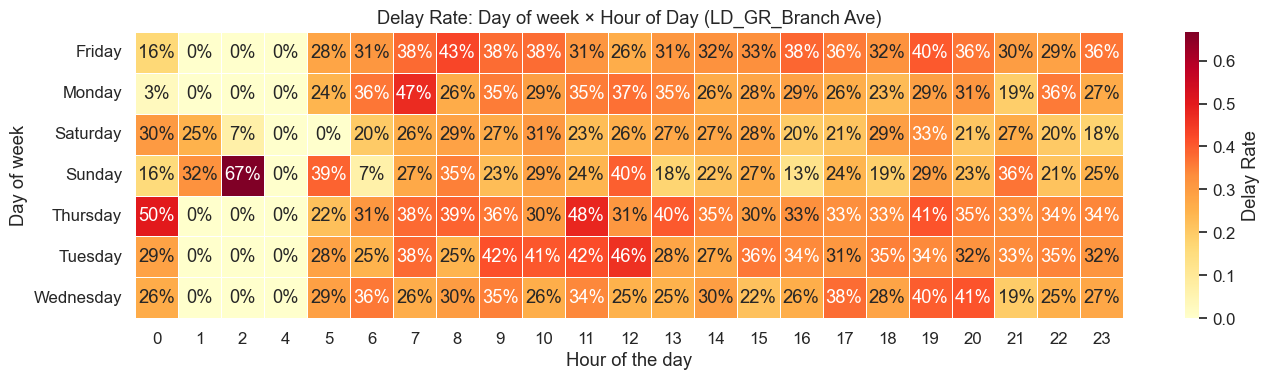

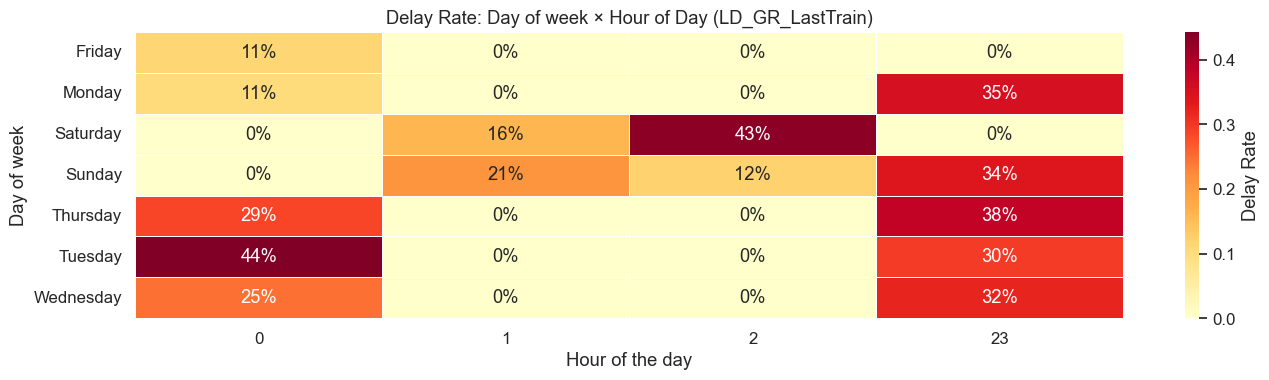

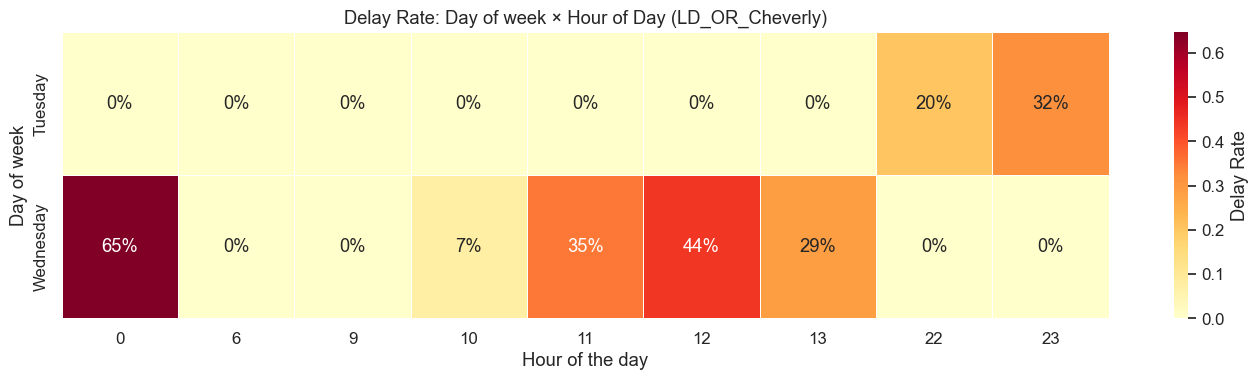

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ftruj\\WMATA-Metro-Delay-Prediction\\reports\\figures\\LD_OR_Vienna/Fairfax-GMUeda_dowhour_matrix.png'

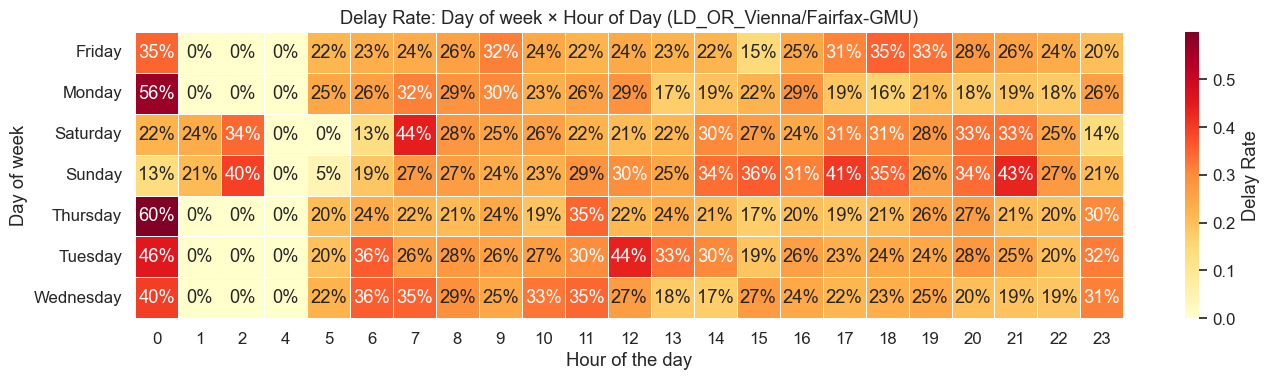

In [26]:
list_line_destination = list(df[['line', 'destination_name']].drop_duplicates().itertuples(index=False, name=None))
print(list_line_destination)

for str_line, str_destination in list_line_destination:
    str_prefix = "LD_" + str_line + "_" + str_destination
    df_line_track = df[(df['line'] == str_line) & (df['destination_name'] == str_destination)].copy()
    df_line_track['str_dow'] = df_line_track['day_of_week'].map(dict_dow)
    # Create matrix per line-destination - if enough data
    if len(df_line_track) > 1000:
        # Delay rate heatmap: day of week × hour
        pivot = df_line_track.groupby(["str_dow", "hour"])["is_delayed"].mean().unstack(fill_value=0)
        fig, ax = plt.subplots(figsize=(14, 4))
        sns.heatmap(pivot, annot=True, fmt=".0%", cmap="YlOrRd", ax=ax,
                    cbar_kws={"label": "Delay Rate"}, linewidths=0.5)
        ax.set_title("Delay Rate: Day of week × Hour of Day (" + str_prefix + ")")
        ax.set_ylabel("Day of week")
        ax.set_xlabel("Hour of the day")
        plt.tight_layout()
        fig.savefig(os.path.join(FIG_DIR, str_prefix + "eda_dowhour_matrix.png"), dpi=150)
        plt.show()